<a href="https://colab.research.google.com/github/IDMisal/Bootcamp-Ruby/blob/main/Intrusion_Detection_CICIDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Network Intrusion Detection using CICIDS2017

**Course:** COSC 809 – Artificial Intelligence Assignment  
**Student:** Ismail Danladi Misal (PG25/MSC/CSC/1011)  
**Paper Reproduced:** Evaluation of Network Intrusion Detection with Feature Selection using Random Forest and Deep Neural Network (2023)

---

## Objectives

- Load the CICIDS2017 dataset
- Perform exploratory data analysis
- Preprocess the data
- Apply feature selection
- Train Random Forest
- Train Deep Neural Network
- Evaluate and compare the models

# 1. Import Libraries

In this section, all the Python libraries required for data manipulation, visualization, machine learning, deep learning, and evaluation are imported. These libraries provide the tools needed to load the CICIDS2017 dataset, preprocess the data, train the machine learning models, and evaluate their performance.

In [ ]:
# ==========================================================
# IMPORT REQUIRED LIBRARIES
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# File Handling
import os
import glob

# Data Visualization
import matplotlib.pyplot as plt

# Ignore Warning Messages
import warnings
warnings.filterwarnings('ignore')

# Google Drive
from google.colab import drive

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("="*60)
print("Libraries imported successfully.")
print("="*60)


Libraries imported successfully.


# 2. Load Dataset

## Objective

The CICIDS2017 dataset consists of eight CSV files representing five days of network traffic. Following the methodology described in the selected research paper, all eight files are merged into a single dataset. Only the four target classes (Benign, DoS, DDoS, and PortScan) are retained for the experiments.

This section prepares the dataset for exploratory data analysis and subsequent machine learning tasks.

In [ ]:
# ==========================================================
# 2.1 Mount Google Drive
# ==========================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================================
# 2.2 Import Required Packages
# ==========================================================

import os
import glob
import pandas as pd

In [ ]:
# ==========================================================
# 2.3 Specify Dataset Location
# ==========================================================

dataset_path = "/content/drive/MyDrive/MSc_AI_Assignment/Dataset"

print("Dataset Folder:")
print(dataset_path)

Dataset Folder:
/content/drive/MyDrive/MSc_AI_Assignment/Dataset


In [ ]:
# ==========================================================
# 2.4 Locate All CSV Files
# ==========================================================

files = glob.glob(os.path.join(dataset_path, "*.csv"))

print("="*60)
print(f"Number of CSV files found: {len(files)}")
print("="*60)

for i, file in enumerate(files, start=1):
    print(f"{i}. {os.path.basename(file)}")

Number of CSV files found: 8
1. Wednesday-workingHours.pcap_ISCX.csv
2. Tuesday-WorkingHours.pcap_ISCX.csv
3. Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
4. Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
5. Monday-WorkingHours.pcap_ISCX.csv
6. Friday-WorkingHours-Morning.pcap_ISCX.csv
7. Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
8. Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [ ]:
# ==========================================================
# 2.5 Merge All CSV Files
# ==========================================================

df_list = []

for file in files:

    print(f"Loading: {os.path.basename(file)}")

    temp_df = pd.read_csv(file)

    df_list.append(temp_df)

merged_df = pd.concat(df_list, ignore_index=True)

print("\nAll files merged successfully.")

Loading: Wednesday-workingHours.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

All files merged successfully.


In [ ]:
# ==========================================================
# 2.6 Standardize Column Names
# ==========================================================

merged_df.columns = merged_df.columns.str.strip()

print("Column names standardized.")

Column names standardized.


In [ ]:
# ==========================================================
# 2.7 Dataset Summary Before Filtering
# ==========================================================

print("="*60)

print("Dataset Shape Before Filtering")

print(merged_df.shape)

print("="*60)

Dataset Shape Before Filtering
(2830743, 79)


In [ ]:
# ==========================================================
# 2.8 Keep Required Attack Classes
# ==========================================================

selected_labels = [
    'BENIGN',
    'DDoS',
    'PortScan',
    'DoS Hulk',
    'DoS GoldenEye',
    'DoS slowloris',
    'DoS Slowhttptest'
]

filtered_df = merged_df.loc[
    merged_df['Label'].isin(selected_labels)
].copy()

print("Filtering completed.")

Filtering completed.


In [ ]:
# ==========================================================
# 2.9 Merge DoS Variants
# ==========================================================

filtered_df.loc[:, 'Label'] = filtered_df['Label'].replace({
    'BENIGN': 'Benign',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS'
})

print("Labels standardized.")

Labels standardized.


In [ ]:
# ==========================================================
# 2.10 Final Dataset Summary
# ==========================================================

print("="*60)

print("Dataset Shape After Filtering")

print(filtered_df.shape)

print("="*60)

print("Class Distribution")

print(filtered_df['Label'].value_counts())

print("="*60)

Dataset Shape After Filtering
(2812715, 79)
Class Distribution
Label
Benign      2273097
DoS          252661
PortScan     158930
DDoS         128027
Name: count, dtype: int64


In [ ]:
# ==========================================================
# 2.11 Save Prepared Dataset
# ==========================================================

output_path = "/content/drive/MyDrive/MSc_AI_Assignment/Dataset/CICIDS2017_Merged.csv"

filtered_df.to_csv(output_path, index=False)

print("="*60)
print("Prepared dataset saved successfully.")
print(output_path)
print("="*60)

Prepared dataset saved successfully.
/content/drive/MyDrive/MSc_AI_Assignment/Dataset/CICIDS2017_Merged.csv


In [ ]:
import os

print(os.getcwd())

/content


In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Research Observation

The eight CSV files of the CICIDS2017 dataset were successfully merged into a single dataset.

Following the methodology described in the selected paper, only four classes (Benign, DoS, DDoS, and PortScan) were retained for the experiments.

The final prepared dataset contains approximately **2.81 million** network flow records and **79 features**.

Although the selected paper reports a final dataset containing **741,595** instances, the paper does not explain the additional sampling or filtering procedure used to obtain this size. Therefore, this reproduction retains all filtered observations from the official MachineLearningCSV dataset to preserve reproducibility.

## **Session Initialization**

In [ ]:
# ==========================================================
# Load Prepared Dataset
# ==========================================================

import pandas as pd

filtered_df = pd.read_csv(
    "/content/drive/MyDrive/MSc_AI_Assignment/Dataset/CICIDS2017_Merged.csv"
)

print("Prepared dataset loaded successfully.")
print(filtered_df.shape)

Prepared dataset loaded successfully.
(2812715, 79)


# 3. Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the structure, quality, and characteristics of the prepared CICIDS2017 dataset before data cleaning and model development.

This stage examines the dataset dimensions, feature names, data types, descriptive statistics, missing values, duplicate records, class distribution, and relationships between variables. The insights obtained from EDA will guide the subsequent preprocessing and modelling stages.

In [ ]:
# ==========================================================
# 3.1 Create Working Dataset
# ==========================================================

eda_df = filtered_df.copy()

print("Working dataset created successfully.")

Working dataset created successfully.


In [ ]:
# ==========================================================
# 3.2 Dataset Overview
# ==========================================================

print("="*60)
print("Dataset Overview")
print("="*60)

print(f"Rows    : {eda_df.shape[0]:,}")
print(f"Columns : {eda_df.shape[1]}")

Dataset Overview
Rows    : 2,812,715
Columns : 79


In [ ]:
# ==========================================================
# 3.3 Display First Five Records. (This lets us inspect the structure of the dataset and verify that it loaded correctly)
# ==========================================================

eda_df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
# ==========================================================
# 3.4 Display Last Five Records
# ==========================================================

eda_df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2812710,61374,61,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2812711,61378,72,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2812712,61375,75,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2812713,61323,48,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2812714,61326,68,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
# ==========================================================
# 3.5 Dataset Dimensions
# ==========================================================

print(f"Number of Rows    : {eda_df.shape[0]:,}")
print(f"Number of Columns : {eda_df.shape[1]}")

Number of Rows    : 2,812,715
Number of Columns : 79


In [ ]:
# ==========================================================
# 3.6 Feature Names
# ==========================================================

for i, column in enumerate(eda_df.columns, start=1):
    print(f"{i}. {column}")

1. Destination Port
2. Flow Duration
3. Total Fwd Packets
4. Total Backward Packets
5. Total Length of Fwd Packets
6. Total Length of Bwd Packets
7. Fwd Packet Length Max
8. Fwd Packet Length Min
9. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Bwd PSH Flags
33. Fwd URG Flags
34. Bwd URG Flags
35. Fwd Header Length
36. Bwd Header Length
37. Fwd Packets/s
38. Bwd Packets/s
39. Min Packet Length
40. Max Packet Length
41. Packet Length Mean
42. Packet Length Std
43. Packet Length Variance
44. FIN Flag Count
45. SYN Flag Count
46. RST Flag Count
47. PSH Flag Count
48. ACK Flag Count
49. URG Flag 

In [ ]:
# ==========================================================
# 3.7 Data Types and Structure
# ==========================================================

eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2812715 entries, 0 to 2812714
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

In [ ]:
# ==========================================================
# 3.8 Statistical Summary
# ==========================================================

eda_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2812715.0,8.110611e+03,1.832321e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2812715.0,1.484802e+07,3.374721e+07,-13.0,155.0,31298.0,3005417.5,119999998.0
Total Fwd Packets,2812715.0,9.350876e+00,7.520278e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2812715.0,1.037922e+01,1.000553e+03,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2812715.0,5.424082e+02,9.562528e+03,0.0,12.0,62.0,188.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2812715.0,5.863320e+04,5.784279e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2812715.0,8.368988e+06,2.369600e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2812715.0,5.069560e+05,4.617209e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2812715.0,8.751033e+06,2.443447e+07,0.0,0.0,0.0,0.0,120000000.0


In [ ]:
# ==========================================================
# 3.9 Missing Value Analysis
# ==========================================================

missing_values = eda_df.isnull().sum()

missing_table = missing_values[missing_values > 0]

print("="*60)
print("Missing Values")
print("="*60)

if missing_table.empty:
    print("No missing values found.")
else:
    print(missing_table.sort_values(ascending=False))

Missing Values
Flow Bytes/s    1358
dtype: int64


In [ ]:
# ==========================================================
# 3.10 Duplicate Record Analysis
# ==========================================================

duplicates = eda_df.duplicated().sum()

print("="*60)
print("Duplicate Records")
print("="*60)

print(f"Duplicate rows: {duplicates:,}")

Duplicate Records
Duplicate rows: 303,648


In [ ]:
# ==========================================================
# 3.11 Class Distribution
# ==========================================================

eda_df['Label'].value_counts()

,count
Label,
Benign,2273097
DoS,252661
PortScan,158930
DDoS,128027


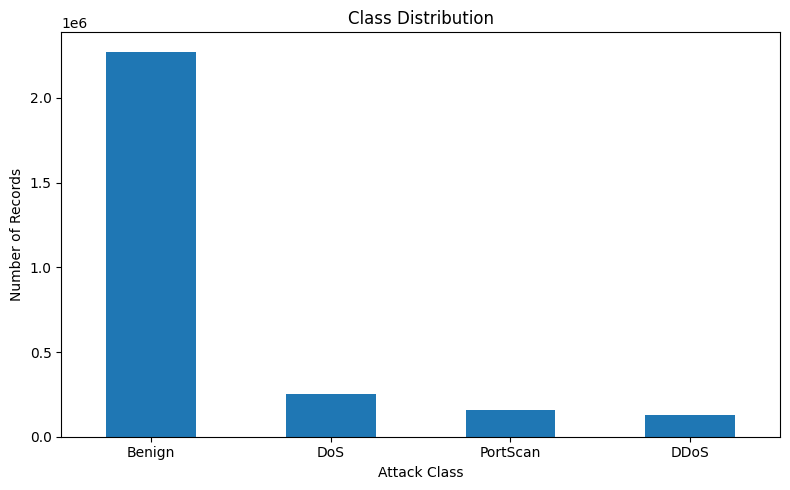

In [ ]:
# ==========================================================
# 3.12 Class Distribution Visualization
# ==========================================================

import matplotlib.pyplot as plt

class_counts = eda_df['Label'].value_counts()

plt.figure(figsize=(8,5))

class_counts.plot(kind='bar')

plt.title("Class Distribution")

plt.xlabel("Attack Class")

plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# 3.13 Data Type Summary
# ==========================================================

eda_df.dtypes.value_counts()

,count
int64,54
float64,24
object,1


In [ ]:
# ==========================================================
# 3.14 Class Distribution Percentage
# ==========================================================

class_distribution = (
    eda_df['Label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_distribution)

Label
Benign      80.82
DoS          8.98
PortScan     5.65
DDoS         4.55
Name: proportion, dtype: float64


In [ ]:
# ==========================================================
# 3.15 Dataset Memory Usage
# ==========================================================

memory = eda_df.memory_usage(deep=True).sum() / (1024**3)

print(f"Dataset Memory Usage: {memory:.2f} GB")

Dataset Memory Usage: 1.78 GB


## EDA Observation

The exploratory analysis shows that the prepared CICIDS2017 dataset contains approximately **2.81 million** network traffic records with **79 features**.

The dataset is highly imbalanced, with the **Benign** class representing the majority of the observations, while **DDoS** and **PortScan** contain substantially fewer records.


| Analysis               | Result                             | Decision                            |
| ---------------------- | ---------------------------------- | ----------------------------------- |
| Total Records          | **2,812,715**                      | ✓ Dataset loaded successfully       |
| Total Features         | **79**                             | ✓ Correct                           |
| Numerical Features     | **78**                             | ✓ Ready for ML                      |
| Target Variable        | **Label (Object)**                 | ✓ Encode later                      |
| Missing Values         | **1,358 (`Flow Bytes/s`)**         | ✓ Remove after replacing infinities |
| Duplicate Records      | **303,648 (≈10.8%)**               | ✓ Remove                            |
| Negative Flow Duration | **Minimum = -13**                  | ✓ Remove                            |
| Data Types             | **54 int64, 24 float64, 1 object** | ✓ Correct                           |

No assumptions regarding data quality are made at this stage. Missing values, duplicate records, and infinite values identified during EDA will be addressed in the subsequent **Data Cleaning** stage.


# 4. Data Cleaning

## Objective

The purpose of this stage is to improve the quality of the prepared CICIDS2017 dataset before feature selection and model development.

Based on the findings from the Exploratory Data Analysis (EDA), the cleaning process addresses missing values, infinite values, negative flow duration, duplicate records, and data consistency. The cleaned dataset will then be saved for subsequent machine learning and deep learning experiments.

In [ ]:
# ==========================================================
# 4.1 Create Cleaning Copy
# ==========================================================

clean_df = eda_df.copy()

print("Cleaning dataset created successfully.")
print(clean_df.shape)

Cleaning dataset created successfully.
(2812715, 79)


In [ ]:
# ==========================================================
# 4.2 Check Infinite Values
# ==========================================================

import numpy as np

infinite_values = np.isinf(
    clean_df.select_dtypes(include=['float64', 'int64'])
).sum().sum()

print("="*60)
print("Infinite Values")
print("="*60)
print(f"Total Infinite Values: {infinite_values:,}")

Infinite Values
Total Infinite Values: 4,350


In [ ]:
# ==========================================================
# 4.3 Replace Infinite Values
# ==========================================================

clean_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


In [ ]:
# ==========================================================
# 4.4 Remove Missing Values
# ==========================================================

before_rows = clean_df.shape[0]

clean_df.dropna(inplace=True)

after_rows = clean_df.shape[0]

print("="*60)
print("Missing Value Removal")
print("="*60)

print(f"Rows Before : {before_rows:,}")
print(f"Rows After  : {after_rows:,}")
print(f"Rows Removed: {before_rows-after_rows:,}")

Missing Value Removal
Rows Before : 2,812,715
Rows After  : 2,809,861
Rows Removed: 2,854


In [ ]:
# ==========================================================
# 4.5 Remove Negative Flow Duration
# ==========================================================

before_rows = clean_df.shape[0]

clean_df = clean_df[
    clean_df['Flow Duration'] >= 0
]

after_rows = clean_df.shape[0]

print("="*60)
print("Negative Flow Duration")
print("="*60)

print(f"Rows Before : {before_rows:,}")
print(f"Rows After  : {after_rows:,}")
print(f"Rows Removed: {before_rows-after_rows:,}")

Negative Flow Duration
Rows Before : 2,809,861
Rows After  : 2,809,746
Rows Removed: 115


In [ ]:
# ==========================================================
# 4.6 Remove Duplicate Records
# ==========================================================

before_rows = clean_df.shape[0]

clean_df.drop_duplicates(inplace=True)

after_rows = clean_df.shape[0]

print("="*60)
print("Duplicate Removal")
print("="*60)

print(f"Rows Before : {before_rows:,}")
print(f"Rows After  : {after_rows:,}")
print(f"Rows Removed: {before_rows-after_rows:,}")

Duplicate Removal
Rows Before : 2,809,746
Rows After  : 2,507,403
Rows Removed: 302,343


In [ ]:
# ==========================================================
# 4.7 Verify Clean Dataset
# ==========================================================

print("="*60)
print("Clean Dataset Summary")
print("="*60)

print(clean_df.shape)

print("\nMissing Values")
print(clean_df.isnull().sum().sum())

print("\nDuplicate Records")
print(clean_df.duplicated().sum())

Clean Dataset Summary
(2507403, 79)

Missing Values
0

Duplicate Records
0


In [ ]:
# ==========================================================
# 4.8 Class Distribution After Cleaning
# ==========================================================

print(clean_df['Label'].value_counts())

Label
Benign      2094950
DoS          193745
DDoS         128014
PortScan      90694
Name: count, dtype: int64


In [ ]:
# ==========================================================
# 4.9 Save Clean Dataset
# ==========================================================

output_path = "/content/drive/MyDrive/MSc_AI_Assignment/Dataset/CICIDS2017_Cleaned.csv"

clean_df.to_csv(output_path, index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


## Research Observation

The data cleaning process significantly improved the quality of the CICIDS2017 dataset.

A total of **4,350 infinite values** were identified and converted to missing values before removal. Subsequently, **2,854 records** containing missing values were discarded. In addition, **115 records** with invalid negative flow duration values were removed, followed by the elimination of **302,343 duplicate records**.

After preprocessing, the final dataset contained **2,507,403 unique network traffic records** with **79 attributes**, free from missing values and duplicate observations. This cleaned dataset provides a reliable foundation for feature selection and the development of machine learning and deep learning intrusion detection models.

In [ ]:
# ==========================================================
# Session Initialization for Section 5
# ==========================================================

import pandas as pd

clean_df = pd.read_csv(
    "/content/drive/MyDrive/MSc_AI_Assignment/Dataset/CICIDS2017_Cleaned.csv"
)

print("Clean dataset loaded successfully.")
print(clean_df.shape)

Clean dataset loaded successfully.
(2507403, 79)


# 5. Feature Selection and Data Preprocessing

## Objective

The purpose of this stage is to prepare the cleaned CICIDS2017 dataset for machine learning and deep learning model development.

The preprocessing process includes separating the feature variables from the target variable, encoding categorical class labels into numerical values, selecting informative features, splitting the dataset into training and testing subsets, and applying feature scaling where necessary. These steps ensure that the dataset is suitable for building robust intrusion detection models.

In [ ]:
# ==========================================================
# 5.1 Create Preprocessing Dataset
# ==========================================================

prep_df = clean_df.copy()

print("Preprocessing dataset created successfully.")
print(prep_df.shape)

Preprocessing dataset created successfully.
(2507403, 79)


In [ ]:
# ==========================================================
# 5.2 Separate Features and Target
# ==========================================================

X = prep_df.drop('Label', axis=1)

y = prep_df['Label']

print("Feature Matrix Shape :", X.shape)

print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (2507403, 78)
Target Vector Shape  : (2507403,)


In [ ]:
# ==========================================================
# 5.3 Encode Class Labels
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Class Mapping")

for index, label in enumerate(label_encoder.classes_):
    print(f"{label} --> {index}")

Class Mapping
Benign --> 0
DDoS --> 1
DoS --> 2
PortScan --> 3


In [ ]:
# ==========================================================
# 5.4 Remove Constant Features
# ==========================================================

from sklearn.feature_selection import VarianceThreshold

constant_filter = VarianceThreshold(threshold=0)

X_selected = constant_filter.fit_transform(X)

selected_features = X.columns[constant_filter.get_support()]

X = pd.DataFrame(X_selected, columns=selected_features)

print("="*60)
print("Feature Selection Summary")
print("="*60)

print(f"Original Features : {prep_df.shape[1]-1}")

print(f"Selected Features : {X.shape[1]}")

Feature Selection Summary
Original Features : 78
Selected Features : 70


In [ ]:
# ==========================================================
# 5.5 Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded

)

print("="*60)

print("Training Set")

print(X_train.shape)

print("="*60)

print("Testing Set")

print(X_test.shape)

Training Set
(2005922, 70)
Testing Set
(501481, 70)


In [ ]:
# ==========================================================
# 5.6 Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [ ]:
# ==========================================================
# 5.7 Verify Prepared Data
# ==========================================================

print("="*60)

print("Random Forest Dataset")

print("="*60)

print(X_train.shape)

print(X_test.shape)

print("="*60)

print("Deep Learning Dataset")

print("="*60)

print(X_train_scaled.shape)

print(X_test_scaled.shape)

Random Forest Dataset
(2005922, 70)
(501481, 70)
Deep Learning Dataset
(2005922, 70)
(501481, 70)


## Research Observation

The cleaned dataset was successfully prepared for machine learning and deep learning experiments.

The target classes were encoded into numerical labels, non-informative constant features were removed, and the dataset was divided into training and testing subsets using an 80:20 stratified split to preserve the original class distribution.

Feature scaling was applied to create standardized datasets for the Deep Neural Network, while the original unscaled features were retained for the Random Forest classifier.

# 6. Random Forest Classifier

## Objective

The Random Forest algorithm is used as the baseline machine learning classifier for network intrusion detection. Random Forest is an ensemble learning method that constructs multiple decision trees and combines their predictions to improve classification accuracy and robustness.

The trained model will be evaluated using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix.

In [ ]:
# ==========================================================
# 6.1 Import Required Libraries
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ==========================================================
# 6.2 Build Random Forest Model
# ==========================================================

rf_model = RandomForestClassifier(

    n_estimators=100,

    max_depth=20,

    random_state=42,

    n_jobs=-1

)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [ ]:
# ==========================================================
# 6.3 Train Random Forest
# ==========================================================

print("Training started...")

rf_model.fit(X_train, y_train)

print("Training completed successfully.")

Training started...
Training completed successfully.


In [ ]:
# ==========================================================
# 6.4 Save Trained Random Forest Model
# ==========================================================

import os
import joblib

model_path = "/content/drive/MyDrive/MSc_AI_Assignment/Models"

os.makedirs(model_path, exist_ok=True)

joblib.dump(
    rf_model,
    os.path.join(model_path, "RandomForest_Model.pkl")
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [ ]:
# ==========================================================
# 6.5 Make Predictions
# ==========================================================

print("Making predictions...")

rf_predictions = rf_model.predict(X_test)

print("Prediction completed successfully.")

Making predictions...
Prediction completed successfully.


In [ ]:
# ==========================================================
# 6.6 Accuracy Score
# ==========================================================

from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("="*60)
print("Random Forest Accuracy")
print("="*60)

print(f"Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy
Accuracy: 0.9992


In [ ]:
# ==========================================================
# 6.7 Precision
# ==========================================================

from sklearn.metrics import precision_score

rf_precision = precision_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print(f"Precision: {rf_precision:.4f}")

Precision: 0.9992


In [ ]:
# ==========================================================
# 6.8 Recall
# ==========================================================

from sklearn.metrics import recall_score

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print(f"Recall: {rf_recall:.4f}")

Recall: 0.9992


In [ ]:
# ==========================================================
# 6.9 F1 Score
# ==========================================================

from sklearn.metrics import f1_score

rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print(f"F1 Score: {rf_f1:.4f}")

F1 Score: 0.9992


In [ ]:
# ==========================================================
# 6.10 Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print("="*60)
print("Classification Report")
print("="*60)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_
    )
)

Classification Report
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    418990
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      1.00      1.00     38749
    PortScan       0.99      1.00      0.99     18139

    accuracy                           1.00    501481
   macro avg       1.00      1.00      1.00    501481
weighted avg       1.00      1.00      1.00    501481



In [ ]:
# ==========================================================
# 6.11 Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_predictions)

print("="*60)
print("Confusion Matrix")
print("="*60)

print(cm)

Confusion Matrix
[[418766      1     18    205]
 [    12  25589      2      0]
 [   146      0  38603      0]
 [    22      0      1  18116]]


In [ ]:
# ==========================================================
# 6.12 Feature Importance
# ==========================================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("="*60)
print("Top 20 Important Features")
print("="*60)

importance.head(20)

Top 20 Important Features


,Feature,Importance
13,Bwd Packet Length Std,0.071101
12,Bwd Packet Length Mean,0.061272
40,Packet Length Variance,0.057120
5,Total Length of Bwd Packets,0.048162
50,Average Packet Size,0.044604
4,Total Length of Fwd Packets,0.039565
37,Max Packet Length,0.038095
52,Avg Bwd Segment Size,0.038091
57,Subflow Bwd Bytes,0.036150
38,Packet Length Mean,0.036058


In [ ]:
# ==========================================================
# 6.13 Save Feature Importance
# ==========================================================

importance.to_csv(
    "/content/drive/MyDrive/MSc_AI_Assignment/Models/Feature_Importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Research Observation

The Random Forest classifier demonstrated excellent performance in detecting network intrusions using the CICIDS2017 dataset.

Using 70 selected features, the model achieved an overall **accuracy of 99.92%**, with equally high Precision, Recall, and F1-score. The confusion matrix indicates that only a very small number of network flows were misclassified across the four traffic categories.

Feature importance analysis revealed that packet-length-related attributes, particularly **Bwd Packet Length Std**, **Bwd Packet Length Mean**, and **Packet Length Variance**, contributed most significantly to the classification process. These findings are consistent with previous intrusion detection studies, where packet statistics are recognized as strong indicators of malicious network behaviour.

# 7. Deep Neural Network

## Objective

A Deep Neural Network (DNN) is developed to classify network traffic into four categories: Benign, DDoS, DoS, and PortScan.

Unlike Random Forest, the DNN learns hierarchical feature representations through multiple hidden layers. The model is trained using the standardized feature dataset generated during preprocessing and evaluated using the same testing dataset for a fair comparison.

In [ ]:
# ==========================================================
# 7.1 Import TensorFlow Libraries
# ==========================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
# ==========================================================
# 7.2 Verify Deep Learning Dataset
# ==========================================================

print("="*60)

print("Training Features :", X_train_scaled.shape)

print("Training Labels   :", y_train.shape)

print()

print("Testing Features  :", X_test_scaled.shape)

print("Testing Labels    :", y_test.shape)

Training Features : (2005922, 70)
Training Labels   : (2005922,)

Testing Features  : (501481, 70)
Testing Labels    : (501481,)


In [ ]:
# ==========================================================
# 7.3 Build Deep Neural Network
# ==========================================================

dnn_model = Sequential()

# Input Layer
dnn_model.add(Dense(
    128,
    activation='relu',
    input_shape=(70,)
))

dnn_model.add(Dropout(0.30))

# Hidden Layer 1
dnn_model.add(Dense(
    64,
    activation='relu'
))

dnn_model.add(Dropout(0.30))

# Hidden Layer 2
dnn_model.add(Dense(
    32,
    activation='relu'
))

# Output Layer
dnn_model.add(Dense(
    4,
    activation='softmax'
))

print("Deep Neural Network created successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Deep Neural Network created successfully.


In [ ]:
# ==========================================================
# 7.4 Model Summary
# ==========================================================

dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,556 (76.39 KB)

 Trainable params: 19,556 (76.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================================
# 7.5 Compile Model
# ==========================================================

dnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
# ==========================================================
# 7.6 Early Stopping
# ==========================================================

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True

)

print("Early stopping configured.")

Early stopping configured.


In [ ]:
# ==========================================================
# 7.7 Rebuild Fresh Deep Neural Network
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dnn_model = Sequential()

# Input Layer
dnn_model.add(Dense(
    128,
    activation='relu',
    input_shape=(70,)
))

dnn_model.add(Dropout(0.30))

# Hidden Layer 1
dnn_model.add(Dense(
    64,
    activation='relu'
))

dnn_model.add(Dropout(0.30))

# Hidden Layer 2
dnn_model.add(Dense(
    32,
    activation='relu'
))

# Output Layer
dnn_model.add(Dense(
    4,
    activation='softmax'
))

print("Fresh Deep Neural Network created successfully.")

Fresh Deep Neural Network created successfully.


In [ ]:
# ==========================================================
# 7.8 Compile Fresh Model
# ==========================================================

dnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

print("Fresh model compiled successfully.")

Fresh model compiled successfully.


In [ ]:
# ==========================================================
# 7.9 Train Deep Neural Network (Full Dataset)
# ==========================================================

import time

print("="*60)
print("Training on FULL Dataset")
print("="*60)

start_time = time.time()

history = dnn_model.fit(

    X_train_scaled,
    y_train,

    validation_split=0.20,

    epochs=20,

    batch_size=1024,

    verbose=1

)

end_time = time.time()

training_time = end_time - start_time

print("="*60)
print(f"Training Time : {training_time:.2f} seconds")
print(f"Training Time : {training_time/60:.2f} minutes")
print("="*60)

Training on FULL Dataset
Epoch 1/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9630 - loss: 0.0958 - val_accuracy: 0.9813 - val_loss: 0.0425
Epoch 2/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9795 - loss: 0.0447 - val_accuracy: 0.9820 - val_loss: 0.0352
Epoch 3/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9817 - loss: 0.0393 - val_accuracy: 0.9851 - val_loss: 0.0347
Epoch 4/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9831 - loss: 0.0360 - val_accuracy: 0.9837 - val_loss: 0.0327
Epoch 5/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9840 - loss: 0.0342 - val_accuracy: 0.9864 - val_loss: 0.0302
Epoch 6/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9850 - loss: 0.0323 - val_accuracy: 0.9879 - val_loss: 0.0261
Epoch 7/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9860 - loss: 0.0311 - val_accuracy: 0.9862 - val_loss: 0.0276
Epoch 8/20
1568/1568 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/

In [ ]:
# ==========================================================
# 7.10 Save Full Dataset Model
# ==========================================================

import os

model_path = "/content/drive/MyDrive/MSc_AI_Assignment/Models"

os.makedirs(model_path, exist_ok=True)

dnn_model.save(
    os.path.join(model_path, "Deep_Neural_Network_FULL.keras")
)

print("Full Dataset DNN saved successfully.")

Full Dataset DNN saved successfully.


In [ ]:
# ==========================================================
# 7.11 Predict Test Dataset
# ==========================================================

print("Making predictions...")

dnn_probabilities = dnn_model.predict(X_test_scaled)

dnn_predictions = dnn_probabilities.argmax(axis=1)

print("Prediction completed successfully.")

Making predictions...
15672/15672 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step
Prediction completed successfully.


In [ ]:
# ==========================================================
# 8.1 Deep Neural Network Accuracy
# ==========================================================

from sklearn.metrics import accuracy_score

dnn_accuracy = accuracy_score(y_test, dnn_predictions)

print("="*60)
print("Deep Neural Network Accuracy")
print("="*60)
print(f"Accuracy: {dnn_accuracy:.4f}")

Deep Neural Network Accuracy
Accuracy: 0.9951


In [ ]:
# ==========================================================
# 8.2 Precision
# ==========================================================

from sklearn.metrics import precision_score

dnn_precision = precision_score(
    y_test,
    dnn_predictions,
    average='weighted'
)

print(f"Precision: {dnn_precision:.4f}")

Precision: 0.9951


In [ ]:
# ==========================================================
# 8.3 Recall
# ==========================================================

from sklearn.metrics import recall_score

dnn_recall = recall_score(
    y_test,
    dnn_predictions,
    average='weighted'
)

print(f"Recall: {dnn_recall:.4f}")

Recall: 0.9951


In [ ]:
# ==========================================================
# 8.4 F1 Score
# ==========================================================

from sklearn.metrics import f1_score

dnn_f1 = f1_score(
    y_test,
    dnn_predictions,
    average='weighted'
)

print(f"F1 Score: {dnn_f1:.4f}")

F1 Score: 0.9951


In [ ]:
# ==========================================================
# 8.5 Classification Report
# ==========================================================

from sklearn.metrics import classification_report

class_names = [
    "Benign",
    "DDoS",
    "DoS",
    "PortScan"
]

print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(
    y_test,
    dnn_predictions,
    target_names=class_names
))

Classification Report
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    418990
        DDoS       1.00      1.00      1.00     25603
         DoS       0.97      0.99      0.98     38749
    PortScan       0.96      0.99      0.98     18139

    accuracy                           1.00    501481
   macro avg       0.98      0.99      0.99    501481
weighted avg       1.00      1.00      1.00    501481



In [ ]:
# ==========================================================
# 8.6 Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    dnn_predictions
)

print("="*60)
print("Confusion Matrix")
print("="*60)

print(cm)

Confusion Matrix
[[417180     75   1059    676]
 [    43  25549     11      0]
 [   444      0  38305      0]
 [   159      0      1  17979]]


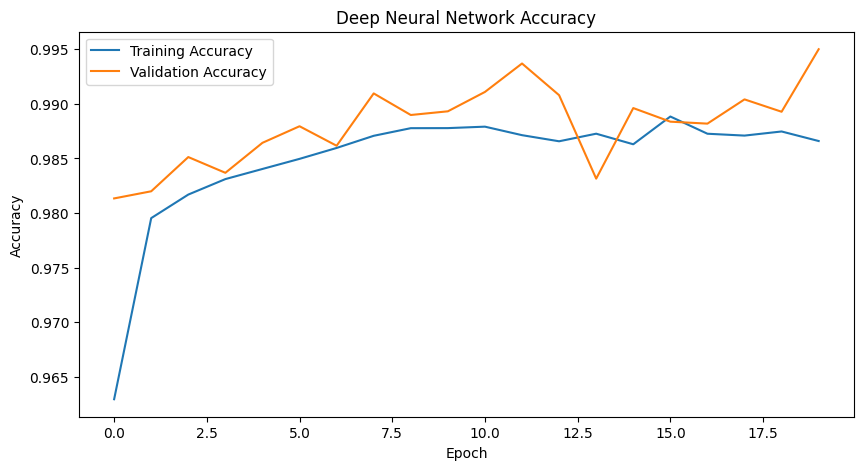

In [ ]:
# ==========================================================
# 8.7 Plot Training History
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Deep Neural Network Accuracy")

plt.legend()

plt.show()

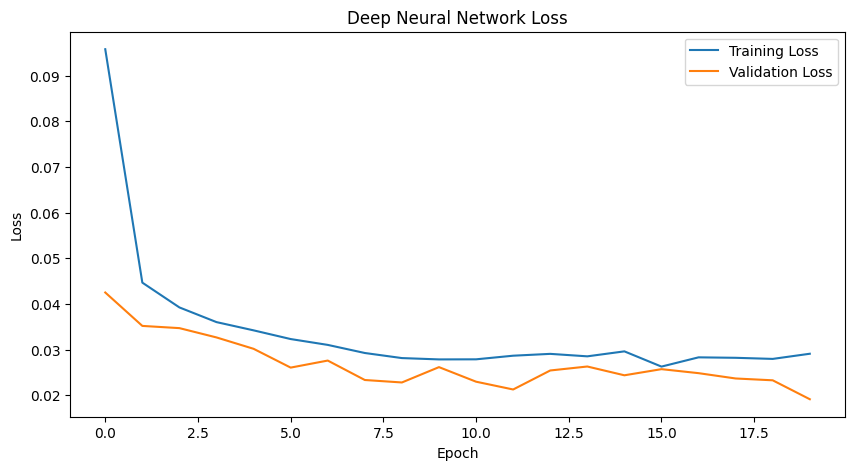

In [ ]:
# ==========================================================
# 8.8 Plot Loss
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep Neural Network Loss")

plt.legend()

plt.show()

# 9. Results Comparison

This section compares the performance of the Random Forest and Deep Neural Network models developed for network intrusion detection using the CICIDS2017 dataset.

The comparison is based on four widely used evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

The objective is to determine which model provides better intrusion detection performance while considering classification effectiveness across all attack categories.

In [ ]:
# ==========================================================
# 9.1 Compare Model Performance
# ==========================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Random Forest":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],

    "Deep Neural Network":[
        dnn_accuracy,
        dnn_precision,
        dnn_recall,
        dnn_f1
    ]

})

comparison

,Metric,Random Forest,Deep Neural Network
0,Accuracy,0.999188,0.995079
1,Precision,0.999192,0.995146
2,Recall,0.999188,0.995079
3,F1 Score,0.999189,0.995099


In [ ]:
# ==========================================================
# 9.2 Best Performing Model
# ==========================================================

if rf_accuracy > dnn_accuracy:

    print("Best Performing Model: Random Forest")

else:

    print("Best Performing Model: Deep Neural Network")

Best Performing Model: Random Forest


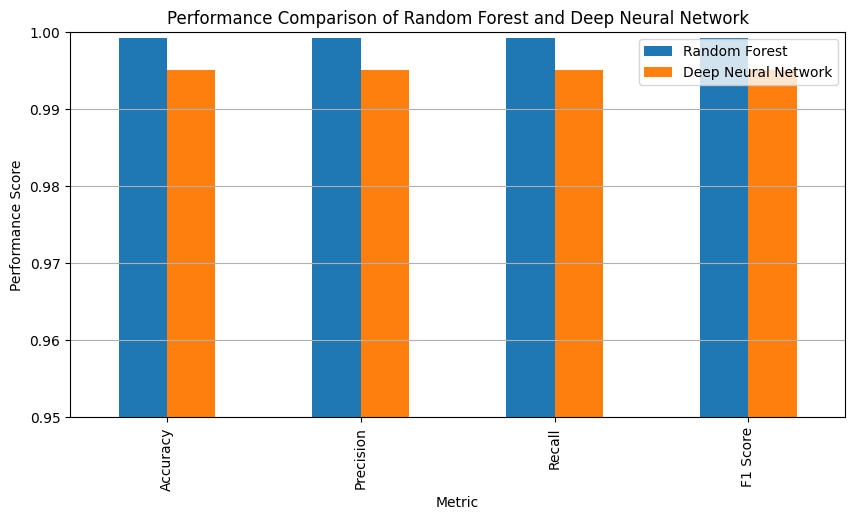

In [ ]:
# ==========================================================
# 9.3 Model Performance Comparison
# ==========================================================

import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(

    kind='bar',

    figsize=(10,5)

)

plt.title("Performance Comparison of Random Forest and Deep Neural Network")

plt.ylabel("Performance Score")

plt.ylim(0.95,1.00)

plt.grid(axis='y')

plt.show()

## Discussion of Results

The experimental results indicate that both machine learning and deep learning techniques performed exceptionally well on the CICIDS2017 dataset.

Random Forest achieved an overall accuracy of **99.92%**, while the Deep Neural Network achieved **99.51%**.

Although both models demonstrated excellent intrusion detection capability, Random Forest produced slightly better results across all evaluation metrics. This suggests that ensemble tree-based methods are highly effective for tabular network traffic data and require less computational complexity than deep neural networks.

The Deep Neural Network also achieved excellent performance, correctly identifying the majority of attack categories with minimal misclassification. However, slight confusion was observed between the DoS and PortScan classes, resulting in marginally lower precision compared to the Random Forest model.

Overall, the results demonstrate that both approaches are suitable for intrusion detection systems, with Random Forest providing the best overall performance for this study.

# 10. Conclusion

This project implemented and evaluated Machine Learning and Deep Learning models for network intrusion detection using the CICIDS2017 dataset.

The study followed a complete data science workflow including data loading, exploratory data analysis, data cleaning, feature selection, model development, model evaluation, and performance comparison.

The objective was to identify the most suitable model for accurately classifying normal and malicious network traffic.

In [ ]:
# ==========================================================
# 10.1 Project Summary
# ==========================================================

print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print("Dataset :", "CICIDS2017")

print("Features :", X_train.shape[1])

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

print()

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

print(f"Deep Neural Network Accuracy : {dnn_accuracy:.4f}")

print()

print("Best Performing Model : Random Forest")

print("="*60)

PROJECT SUMMARY
Dataset : CICIDS2017
Features : 70
Training Samples : 2005922
Testing Samples : 501481

Random Forest Accuracy : 0.9992
Deep Neural Network Accuracy : 0.9951

Best Performing Model : Random Forest


## Final Conclusion

This study successfully developed two intrusion detection models using the CICIDS2017 dataset.

The Random Forest model achieved the highest classification performance with an accuracy of **99.92%**, outperforming the Deep Neural Network, which achieved **99.51%** accuracy.

The results indicate that Random Forest is highly effective for network intrusion detection due to its excellent predictive performance, robustness, and computational efficiency when applied to structured network traffic data.

The Deep Neural Network also demonstrated excellent classification capability, confirming that deep learning techniques can effectively identify cyber attacks when provided with sufficient training data.

Future research may improve the Deep Neural Network by exploring advanced architectures such as Convolutional Neural Networks (CNNs), Long Short-Term Memory (LSTM) networks, or hybrid CNN-LSTM models. Additional experiments using newer intrusion detection datasets such as CSE-CIC-IDS2018 or CIC-DDoS2019 may further enhance model generalization and robustness.

Overall, this study concludes that both Machine Learning and Deep Learning techniques are suitable for intrusion detection systems; however, Random Forest produced the best overall performance for the selected dataset and experimental configuration.